In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [3]:
dataset_path = "20-newsgroups"

categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.space",
    "talk.politics.misc"
]

documents = []
labels = []

for category in categories:

    file_path = os.path.join(
        dataset_path,
        category + ".txt"
    )

    with open(
        file_path,
        "r",
        encoding="latin1"
    ) as file:

        content = file.read()

    parts = re.split(
        r"\n\s*\n(?=From:|Newsgroups?:|Path:)",
        content
    )

    for document in parts:

        document = document.strip()

        if len(document) > 20:

            documents.append(document)
            labels.append(category)

df = pd.DataFrame({
    "text": documents,
    "category": labels
})

print("Dataset Shape:", df.shape)
print("\nCategories:")
print(df["category"].unique())

print("\nClass Distribution:")
print(df["category"].value_counts())

Dataset Shape: (7984, 2)

Categories:
<StringArray>
['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']
Length: 4, dtype: str

Class Distribution:
category
comp.graphics         2450
rec.sport.baseball    1988
sci.space             1982
talk.politics.misc    1564
Name: count, dtype: int64


In [4]:
df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

print("Average Document Length:",
      df["word_count"].mean())

print("Minimum Document Length:",
      df["word_count"].min())

print("Maximum Document Length:",
      df["word_count"].max())

print("Median Document Length:",
      df["word_count"].median())

Average Document Length: 286.7810621242485
Minimum Document Length: 5
Maximum Document Length: 9222
Median Document Length: 162.0


In [5]:
length_summary = df.groupby(
    "category"
)["word_count"].agg(
    ["count", "mean", "min", "max", "median"]
)

print(length_summary)

                    count        mean  min   max  median
category                                                
comp.graphics        2450  249.116735    5  9222   119.0
rec.sport.baseball   1988  225.633803   14  2570   161.0
sci.space            1982  281.677094    9  9134   176.0
talk.politics.misc   1564  429.974425   11  7985   237.5


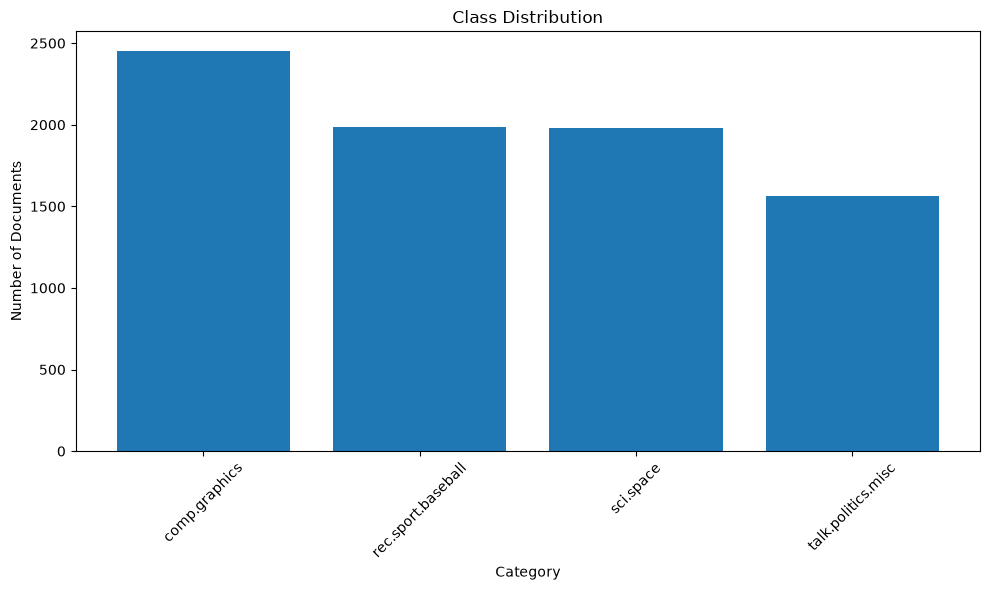

In [6]:
class_counts = df["category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of Documents")
plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

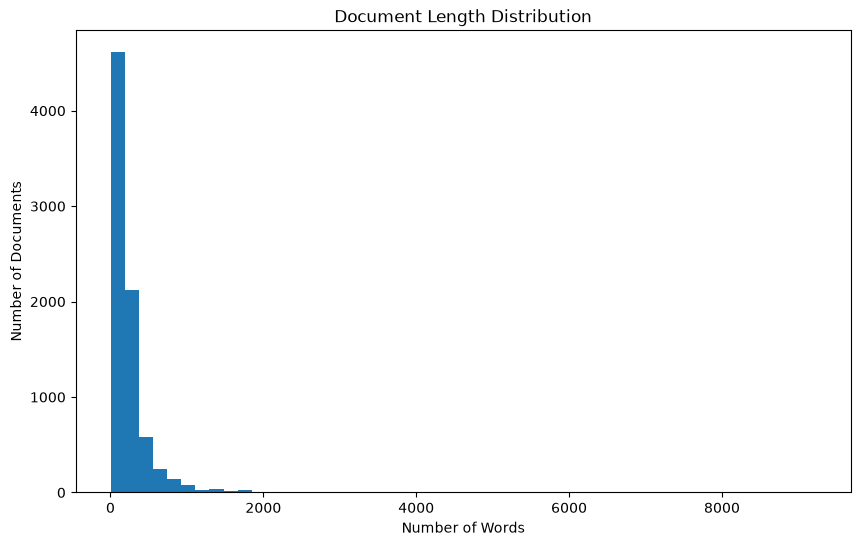

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["word_count"],
    bins=50
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")

plt.show()

In [8]:
for category in categories:

    print("\n" + "=" * 70)
    print(category)
    print("=" * 70)

    sample = df[
        df["category"] == category
    ].iloc[0]["text"]

    print(sample[:1500])


comp.graphics
From: lipman@oasys.dt.navy.mil (Robert Lipman)
Subject: CALL FOR PRESENTATIONS: Navy SciViz/VR Seminar


			CALL FOR PRESENTATIONS
	
      NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR

			Tuesday, June 22, 1993

	    Carderock Division, Naval Surface Warfare Center
	      (formerly the David Taylor Research Center)
			  Bethesda, Maryland

SPONSOR: NESS (Navy Engineering Software System) is sponsoring a 
one-day Navy Scientific Visualization and Virtual Reality Seminar.  
The purpose of the seminar is to present and exchange information for
Navy-related scientific visualization and virtual reality programs, 
research, developments, and applications.

PRESENTATIONS: Presentations are solicited on all aspects of 
Navy-related scientific visualization and virtual reality.  All 
current work, works-in-progress, and proposed work by Navy 
organizations will be considered.  Four types of presentations are 
available.

     1. Regular presentation: 20-30 minutes in

In [9]:
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True
)

X = vectorizer.fit_transform(
    df["text"]
)

vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary Size:",
      len(vocabulary))

print("Matrix Shape:",
      X.shape)

Vocabulary Size: 47243
Matrix Shape: (7984, 47243)


In [10]:
word_counts = np.asarray(
    X.sum(axis=0)
).ravel()

word_frequency = pd.DataFrame({
    "word": vocabulary,
    "frequency": word_counts
})

word_frequency = word_frequency.sort_values(
    "frequency",
    ascending=False
)

print(word_frequency.head(20))

              word  frequency
19931          edu      14485
41749      subject       8533
32062    newsgroup       7742
19167  document_id       7458
15889          com       6967
46712       writes       6301
40655        space       6049
11375      article       5477
23554     graphics       4721
19246          don       4718
28836         like       4317
27399         just       4308
43054        think       3857
34147       people       3803
27906         know       3593
43257         time       3203
25588        image       3161
12257     baseball       3148
19188         does       2712
23380         good       2704


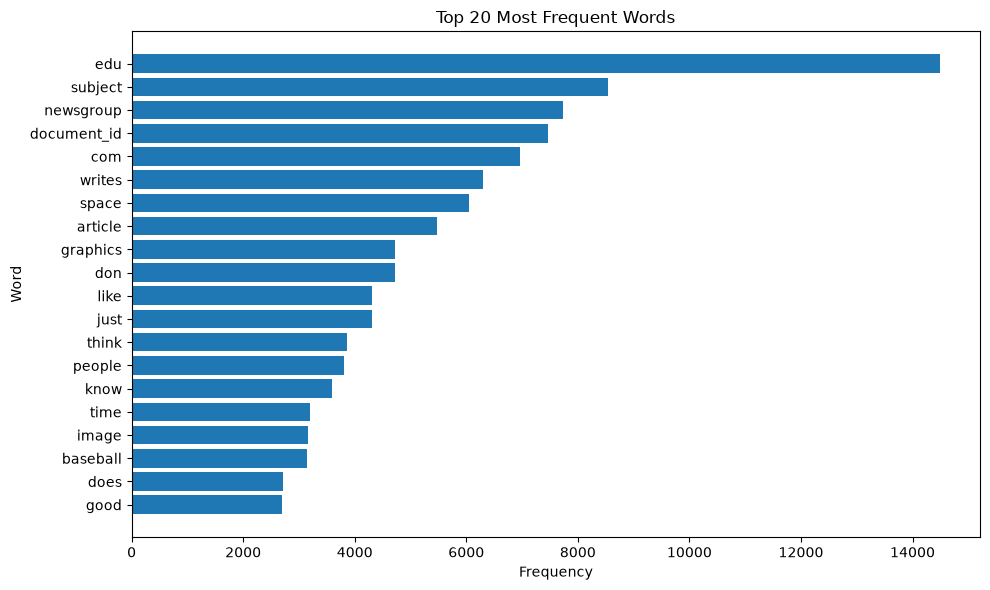

In [11]:
top_words = word_frequency.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_words["word"][::-1],
    top_words["frequency"][::-1]
) 

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words")

plt.tight_layout()
plt.show()

In [12]:
category_word_frequencies = {}

for category in categories:

    category_data = df[
        df["category"] == category
    ]

    category_X = vectorizer.transform(
        category_data["text"]
    )

    frequencies = np.asarray(
        category_X.sum(axis=0)
    ).ravel()

    category_word_frequencies[
        category
    ] = frequencies

    category_words = pd.DataFrame({
        "word": vocabulary,
        "frequency": frequencies
    })

    category_words = category_words.sort_values(
        "frequency",
        ascending=False
    )

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    print(category_words.head(10))


comp.graphics
              word  frequency
23554     graphics       4683
19931          edu       4053
25588        image       2985
41749      subject       2683
16021         comp       2441
32062    newsgroup       2124
19167  document_id       1946
27271         jpeg       1902
21781         file       1711
15889          com       1599

rec.sport.baseball
              word  frequency
19931          edu       4140
12257     baseball       3130
40936        sport       2070
41749      subject       2054
36890          rec       2044
32062    newsgroup       2022
19167  document_id       1988
46712       writes       1698
15889          com       1548
46993         year       1484

sci.space
              word  frequency
40655        space       5638
19931          edu       3364
39039          sci       2298
41749      subject       2128
32062    newsgroup       2010
19167  document_id       1974
31733         nasa       1768
46712       writes       1586
15889          com      

In [13]:
total_documents = len(df)

class_probability = {}

for category in categories:

    count = len(
        df[df["category"] == category]
    )

    class_probability[category] = (
        count / total_documents
    )

print("Class Probabilities:")

for category, probability in class_probability.items():

    print(
        category,
        ":",
        probability
    )

Class Probabilities:
comp.graphics : 0.3068637274549098
rec.sport.baseball : 0.24899799599198397
sci.space : 0.24824649298597196
talk.politics.misc : 0.19589178356713427


In [14]:
word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

word_counts_by_class = {}

total_words_by_class = {}

for category in categories:

    category_data = df[
        df["category"] == category
    ]

    category_X = vectorizer.transform(
        category_data["text"]
    )

    frequencies = np.asarray(
        category_X.sum(axis=0)
    ).ravel()

    word_counts_by_class[
        category
    ] = frequencies

    total_words_by_class[
        category
    ] = frequencies.sum()

print(total_words_by_class)

{'comp.graphics': np.int64(382499), 'rec.sport.baseball': np.int64(258222), 'sci.space': np.int64(330928), 'talk.politics.misc': np.int64(340972)}


In [15]:
def word_probability(word, category):

    vocabulary_size = len(vocabulary)

    if word not in word_to_index:

        return 1 / (
            total_words_by_class[category]
            + vocabulary_size
        )

    index = word_to_index[word]

    word_count = word_counts_by_class[
        category
    ][index]

    probability = (
        word_count + 1
    ) / (
        total_words_by_class[category]
        + vocabulary_size
    )

    return probability

In [16]:
test_words = [
    "space",
    "computer",
    "baseball",
    "government"
]

for word in test_words:

    print("\nWord:", word)

    for category in categories:

        probability = word_probability(
            word,
            category
        )

        print(
            category,
            ":",
            probability
        )


Word: space
comp.graphics : 0.0008190961088280876
rec.sport.baseball : 6.874764702993797e-05
sci.space : 0.014911243855292976
talk.politics.misc : 0.00010561158121144211

Word: computer
comp.graphics : 0.0021059147116176684
rec.sport.baseball : 0.00013422159658225984
sci.space : 0.000314672462986321
talk.politics.misc : 0.0001159151501101194

Word: baseball
comp.graphics : 2.326977581897976e-06
rec.sport.baseball : 0.010249946802415989
sci.space : 2.3798757704847807e-05
talk.politics.misc : 2.833481447136252e-05

Word: government
comp.graphics : 3.7231641310367614e-05
rec.sport.baseball : 3.601067225377703e-05
sci.space : 0.0007324728760269825
talk.politics.misc : 0.003567610731167008


In [17]:
sample_document = df.iloc[0]["text"]

sample_category = df.iloc[0]["category"]

print("Actual Category:")
print(sample_category)

print("\nSample Document:")
print(sample_document[:1000])

Actual Category:
comp.graphics

Sample Document:
From: lipman@oasys.dt.navy.mil (Robert Lipman)
Subject: CALL FOR PRESENTATIONS: Navy SciViz/VR Seminar


			CALL FOR PRESENTATIONS
	
      NAVY SCIENTIFIC VISUALIZATION AND VIRTUAL REALITY SEMINAR

			Tuesday, June 22, 1993

	    Carderock Division, Naval Surface Warfare Center
	      (formerly the David Taylor Research Center)
			  Bethesda, Maryland

SPONSOR: NESS (Navy Engineering Software System) is sponsoring a 
one-day Navy Scientific Visualization and Virtual Reality Seminar.  
The purpose of the seminar is to present and exchange information for
Navy-related scientific visualization and virtual reality programs, 
research, developments, and applications.

PRESENTATIONS: Presentations are solicited on all aspects of 
Navy-related scientific visualization and virtual reality.  All 
current work, works-in-progress, and proposed work by Navy 
organizations will be considered.  Four types of presentations are 
available.

     1. Regu

In [18]:
sample_words = re.findall(
    r"\b[a-zA-Z]+\b",
    sample_document.lower()
)

sample_words = [
    word
    for word in sample_words
    if word in word_to_index
]

sample_words = list(
    dict.fromkeys(sample_words)
)

print("Words Used:")
print(sample_words[:20])

Words Used:
['lipman', 'oasys', 'dt', 'navy', 'mil', 'robert', 'subject', 'presentations', 'sciviz', 'vr', 'seminar', 'scientific', 'visualization', 'virtual', 'reality', 'tuesday', 'june', 'carderock', 'division', 'naval']


In [19]:
def naive_bayes_score(
    words,
    category
):

    prior = class_probability[
        category
    ]

    score = np.log(prior)

    for word in words:

        probability = word_probability(
            word,
            category
        )

        score += np.log(
            probability
        )

    return score

In [20]:
scores = {}

for category in categories:

    scores[category] = naive_bayes_score(
        sample_words,
        category
    )

print("Naive Bayes Scores:")

for category, score in scores.items():

    print(
        category,
        ":",
        score
    )

Naive Bayes Scores:
comp.graphics : -1142.6651778901619
rec.sport.baseball : -1340.847419683214
sci.space : -1251.1721061307178
talk.politics.misc : -1299.0965537052823


In [21]:
prediction = max(
    scores,
    key=scores.get
)

print("Actual Category:",
      sample_category)

print("Predicted Category:",
      prediction)

Actual Category: comp.graphics
Predicted Category: comp.graphics


In [22]:
for word in sample_words[:10]:

    print("\nWord:", word)

    for category in categories:

        probability = word_probability(
            word,
            category
        )

        print(
            category,
            ":",
            probability
        )


Word: lipman
comp.graphics : 0.00010006003602161297
rec.sport.baseball : 3.2736974776160934e-06
sci.space : 2.6443064116497563e-06
talk.politics.misc : 2.57589222466932e-06

Word: oasys
comp.graphics : 6.748234987504131e-05
rec.sport.baseball : 8.838983189563453e-05
sci.space : 2.6443064116497563e-06
talk.politics.misc : 7.72767667400796e-06

Word: dt
comp.graphics : 0.00010471399118540892
rec.sport.baseball : 8.838983189563453e-05
sci.space : 7.932919234949269e-06
talk.politics.misc : 7.72767667400796e-06

Word: navy
comp.graphics : 0.000388605256176962
rec.sport.baseball : 0.00016695857135842076
sci.space : 6.61076602912439e-05
talk.politics.misc : 0.00022925440799556946

Word: mil
comp.graphics : 0.0005119350680175547
rec.sport.baseball : 0.0002651694956869036
sci.space : 0.00013485962699413758
talk.politics.misc : 5.409373671805571e-05

Word: robert
comp.graphics : 0.0005096080904356567
rec.sport.baseball : 0.000350285630104922
sci.space : 0.00028822939886982344
talk.politics.misc

In [23]:
words = sample_words[:3]

print("Selected Words:")
print(words)

for category in categories:

    probabilities = []

    for word in words:

        probability = word_probability(
            word,
            category
        )

        probabilities.append(
            probability
        )

    combined_probability = np.prod(
        probabilities
    )

    print("\nCategory:", category)

    print(
        "Individual probabilities:",
        probabilities
    )

    print(
        "Combined probability:",
        combined_probability
    )

Selected Words:
['lipman', 'oasys', 'dt']

Category: comp.graphics
Individual probabilities: [np.float64(0.00010006003602161297), np.float64(6.748234987504131e-05), np.float64(0.00010471399118540892)]
Combined probability: 7.070588543111623e-13

Category: rec.sport.baseball
Individual probabilities: [np.float64(3.2736974776160934e-06), np.float64(8.838983189563453e-05), np.float64(8.838983189563453e-05)]
Combined probability: 2.557662050493029e-14

Category: sci.space
Individual probabilities: [np.float64(2.6443064116497563e-06), np.float64(2.6443064116497563e-06), np.float64(7.932919234949269e-06)]
Combined probability: 5.546979857280445e-17

Category: talk.politics.misc
Individual probabilities: [np.float64(2.57589222466932e-06), np.float64(7.72767667400796e-06), np.float64(7.72767667400796e-06)]
Combined probability: 1.538245219221481e-16


In [24]:
print("Total Documents:", len(df))

print(
    "Total Vocabulary:",
    len(vocabulary)
)

print(
    "Number of Categories:",
    len(categories)
)

print("\nClass Distribution:")

for category in categories:

    print(
        category,
        ":",
        len(df[df["category"] == category])
    )

print("\nClass Probabilities:")

for category in categories:

    print(
        category,
        ":",
        class_probability[category]
    )

Total Documents: 7984
Total Vocabulary: 47243
Number of Categories: 4

Class Distribution:
comp.graphics : 2450
rec.sport.baseball : 1988
sci.space : 1982
talk.politics.misc : 1564

Class Probabilities:
comp.graphics : 0.3068637274549098
rec.sport.baseball : 0.24899799599198397
sci.space : 0.24824649298597196
talk.politics.misc : 0.19589178356713427


In [25]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["category"],
    test_size=0.2,
    random_state=42,
    stratify=df["category"]
)

print("Training Documents:", len(X_train))
print("Testing Documents:", len(X_test))

Training Documents: 6387
Testing Documents: 1597


In [27]:
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    token_pattern=r"\b[a-zA-Z]{2,}\b",
    min_df=2
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

vocabulary = vectorizer.get_feature_names_out()

print("Training BOW Shape:", X_train_bow.shape)
print("Testing BOW Shape:", X_test_bow.shape)
print("Vocabulary Size:", len(vocabulary))

Training BOW Shape: (6387, 31015)
Testing BOW Shape: (1597, 31015)
Vocabulary Size: 31015


In [28]:
X_train_array = X_train_bow.toarray()
X_test_array = X_test_bow.toarray()

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

In [29]:
classes = np.unique(y_train_array)

class_prior = {}

for category in classes:

    count = np.sum(
        y_train_array == category
    )

    class_prior[category] = (
        count / len(y_train_array)
    )

In [30]:
print("\nClass Prior Probabilities:")

for category in classes:

    print(
        category,
        ":",
        class_prior[category]
    )


Class Prior Probabilities:
comp.graphics : 0.3068733364646939
rec.sport.baseball : 0.24894316580554252
sci.space : 0.24831689369030843
talk.politics.misc : 0.19586660403945513


In [31]:
word_counts = {}

total_words = {}

for category in classes:

    class_documents = X_train_array[
        y_train_array == category
    ]

    counts = class_documents.sum(
        axis=0
    )

    word_counts[category] = counts

    total_words[category] = counts.sum()

In [32]:
vocabulary_size = len(vocabulary)

word_probability = {}

for category in classes:

    word_probability[category] = (
        word_counts[category] + 1
    ) / (
        total_words[category]
        + vocabulary_size
    )

In [33]:
word_probability["sci.space"]

array([3.58775285e-06, 3.58775285e-06, 3.58775285e-06, ...,
       3.58775285e-06, 3.58775285e-06, 3.58775285e-06], shape=(31015,))

In [34]:
word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

In [35]:
test_word = "space"

index = word_to_index[test_word]

print("\nProbability of:", test_word)

for category in classes:

    probability = word_probability[
        category
    ][index]

    print(
        category,
        ":",
        probability
    )


Probability of: space
comp.graphics : 0.0008249281945093848
rec.sport.baseball : 7.813613152609057e-05
sci.space : 0.01648931208426914
talk.politics.misc : 0.00011049723756906077


In [36]:
def predict_document(document):

    scores = {}

    for category in classes:

        score = np.log(
            class_prior[category]
        )

        for word_index, word_count in enumerate(document):

            if word_count > 0:

                probability = word_probability[
                    category
                ][word_index]

                score += (
                    word_count
                    * np.log(probability)
                )

        scores[category] = score

    prediction = max(
        scores,
        key=scores.get
    )

    return prediction

In [37]:
prediction = predict_document(
    X_test_array[0]
)

print("Actual Class:")
print(y_test_array[0])

print("\nPredicted Class:")
print(prediction)

Actual Class:
rec.sport.baseball

Predicted Class:
rec.sport.baseball


In [38]:
predictions = []

for document in X_test_array:

    prediction = predict_document(
        document
    )

    predictions.append(
        prediction
    )

In [39]:
accuracy = accuracy_score(
    y_test_array,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9956167814652473


In [40]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_array,
        predictions
    )
)


Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.99      1.00      1.00       490
rec.sport.baseball       1.00      1.00      1.00       398
         sci.space       0.99      0.99      0.99       396
talk.politics.misc       0.99      0.99      0.99       313

          accuracy                           1.00      1597
         macro avg       1.00      1.00      1.00      1597
      weighted avg       1.00      1.00      1.00      1597



In [41]:
cm = confusion_matrix(
    y_test_array,
    predictions,
    labels=classes
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[489   0   1   0]
 [  0 398   0   0]
 [  2   0 392   2]
 [  1   0   1 311]]


In [42]:
np.random.seed(42)

indices = np.arange(len(X_train_array))

np.random.shuffle(indices)

validation_size = int(0.2 * len(indices))

validation_indices = indices[:validation_size]
training_indices = indices[validation_size:]

X_train_part = X_train_array[training_indices]
y_train_part = y_train_array[training_indices]

X_validation = X_train_array[validation_indices]
y_validation = y_train_array[validation_indices]

print("Training:", len(X_train_part))
print("Validation:", len(X_validation))
print("Testing:", len(X_test_array))

Training: 5110
Validation: 1277
Testing: 1597


In [43]:
def train_naive_bayes(X, y, alpha):

    classes = np.unique(y)

    priors = {}
    word_probabilities = {}

    vocabulary_size = X.shape[1]

    for category in classes:

        class_documents = X[
            y == category
        ]

        document_count = len(
            class_documents
        )

        priors[category] = (
            document_count / len(X)
        )

        word_counts_class = (
            class_documents.sum(axis=0)
        )

        total_words_class = (
            word_counts_class.sum()
        )

        probabilities = (
            word_counts_class + alpha
        ) / (
            total_words_class
            + alpha * vocabulary_size
        )

        word_probabilities[
            category
        ] = probabilities

    return priors, word_probabilities

In [44]:
def predict_naive_bayes(
    X,
    priors,
    word_probabilities
):

    predictions = []

    classes = list(priors.keys())

    for document in X:

        scores = {}

        for category in classes:

            score = np.log(
                priors[category]
            )

            probabilities = (
                word_probabilities[
                    category
                ]
            )

            word_indices = np.where(
                document > 0
            )[0]

            for index in word_indices:

                count = document[index]

                score += (
                    count
                    * np.log(
                        probabilities[index]
                    )
                )

            scores[category] = score

        prediction = max(
            scores,
            key=scores.get
        )

        predictions.append(
            prediction
        )

    return np.array(predictions)

In [45]:
alphas = [
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
]

validation_accuracies = []

for alpha in alphas:

    priors, probabilities = train_naive_bayes(
        X_train_part,
        y_train_part,
        alpha
    )

    validation_predictions = predict_naive_bayes(
        X_validation,
        priors,
        probabilities
    )

    accuracy = np.mean(
        validation_predictions == y_validation
    )

    validation_accuracies.append(
        accuracy
    )

    print(
        "Alpha:",
        alpha,
        "Validation Accuracy:",
        accuracy
    )

Alpha: 0.1 Validation Accuracy: 0.9968676585747847
Alpha: 0.5 Validation Accuracy: 0.9968676585747847
Alpha: 1.0 Validation Accuracy: 0.9960845732184808
Alpha: 2.0 Validation Accuracy: 0.9960845732184808
Alpha: 5.0 Validation Accuracy: 0.995301487862177


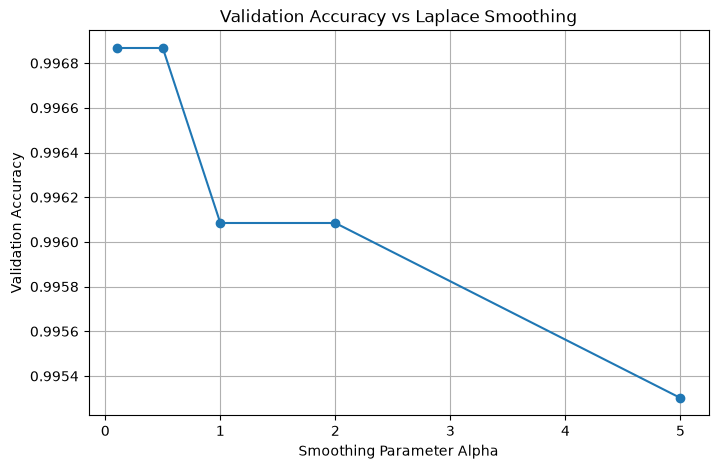

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    alphas,
    validation_accuracies,
    marker="o"
)

plt.xlabel("Smoothing Parameter Alpha")
plt.ylabel("Validation Accuracy")
plt.title(
    "Validation Accuracy vs Laplace Smoothing"
)

plt.grid(True)

plt.show()

In [47]:
best_index = np.argmax(
    validation_accuracies
)

best_alpha = alphas[
    best_index
]

best_accuracy = validation_accuracies[
    best_index
]

print("Best Alpha:", best_alpha)
print(
    "Best Validation Accuracy:",
    best_accuracy
)

Best Alpha: 0.1
Best Validation Accuracy: 0.9968676585747847


In [48]:
final_priors, final_word_probabilities = train_naive_bayes(
    X_train_array,
    y_train_array,
    best_alpha
)

In [49]:
vocabulary
final_word_probabilities

{'comp.graphics': array([1.14177745e-05, 3.68315307e-07, 2.24672337e-05, ...,
        3.68315307e-07, 3.68315307e-07, 3.68315307e-07], shape=(31015,)),
 'rec.sport.baseball': array([1.27072508e-04, 5.17253652e-04, 5.27271817e-07, ...,
        3.74362990e-05, 3.74362990e-05, 1.10727081e-05], shape=(31015,)),
 'sci.space': array([3.98704211e-07, 3.98704211e-07, 3.98704211e-07, ...,
        3.98704211e-07, 3.98704211e-07, 3.98704211e-07], shape=(31015,)),
 'talk.politics.misc': array([3.82136641e-07, 4.20350305e-06, 3.82136641e-07, ...,
        3.82136641e-07, 3.82136641e-07, 3.82136641e-07], shape=(31015,))}

In [50]:
for category in classes:

    probabilities = final_word_probabilities[
        category
    ]

    top_indices = np.argsort(
        probabilities
    )[-10:][::-1]

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    for index in top_indices:

        print(
            vocabulary[index],
            ":",
            probabilities[index]
        )


comp.graphics
graphics : 0.013366530819704132
edu : 0.01155441950745194
image : 0.008629995966947385
subject : 0.007863900127621254
comp : 0.006976260236863574
newsgroup : 0.006221213856758494
jpeg : 0.005937611070084878
file : 0.005042604873179831
com : 0.0046079928104852
images : 0.004129182910906368

rec.sport.baseball
edu : 0.01765358768925763
baseball : 0.013229777148566742
sport : 0.008758512144388114
subject : 0.008668875935577929
rec : 0.008621421472090184
newsgroup : 0.00850014895428817
writes : 0.0071608785403007025
com : 0.006707424778084474
year : 0.006427970715323309
article : 0.005958698798611165

sci.space
space : 0.018320857214054326
edu : 0.010908945925741341
sci : 0.00724884126588587
subject : 0.00676640917019686
newsgroup : 0.006411562422128083
nasa : 0.005849389484176426
writes : 0.005024071766758036
com : 0.004266533765262895
article : 0.0040193371542486915
like : 0.0037123349115375033

talk.politics.misc
edu : 0.00878952487040791
com : 0.007436761162688942
people

In [51]:
for category in classes:

    category_probability = (
        final_word_probabilities[
            category
        ]
    )

    other_probabilities = []

    for other_category in classes:

        if other_category != category:

            other_probabilities.append(
                final_word_probabilities[
                    other_category
                ]
            )

    average_other_probability = np.mean(
        other_probabilities,
        axis=0
    )

    association_score = (
        category_probability
        /
        average_other_probability
    )

    top_indices = np.argsort(
        association_score
    )[-10:][::-1]

    print("\n" + "=" * 60)
    print("Top Associated Words:", category)
    print("=" * 60)

    for index in top_indices:

        print(
            vocabulary[index],
            ":",
            association_score[index]
        )


Top Associated Words: comp.graphics
tiff : 3540.0837185197447
polygon : 2408.202978167452
vga : 2104.1156150877314
siggraph : 2070.328130301096
quicktime : 2053.4343879077783
vesa : 1800.0282520080111
pov : 1656.43144166481
jfif : 1656.43144166481
cview : 1504.3877601249499
phigs : 1495.9408889282909

Top Associated Words: rec.sport.baseball
pitcher : 5177.023033701821
pitching : 4929.252721001388
hitter : 4392.417043483783
batting : 3786.7562791049477
mets : 3594.0460358935
jays : 3497.6909142877753
pitchers : 2919.5601846534323
phillies : 2850.7350977922015
alomar : 2713.084924069739
rbi : 2506.6096634860446

Top Associated Words: sci.space
spacecraft : 5215.167525900359
lunar : 3942.0338272422205
planets : 1957.4430616868872
nsmca : 1863.8302897267301
pluto : 1592.353251042274
orbiter : 1517.4630334741482
higgins : 1498.740479082117
kilometers : 1395.766429925944
km : 1339.5987667498498
larson : 1133.6506684375038

Top Associated Words: talk.politics.misc
cramer : 6989.400644799934

In [52]:
selected_words = [
    "space",
    "computer",
    "baseball",
    "government",
    "nasa",
    "game"
]

In [53]:
probability_table = []

for word in selected_words:

    if word in word_to_index:

        index = word_to_index[word]

        row = {
            "word": word
        }

        for category in classes:

            row[category] = (
                final_word_probabilities[
                    category
                ][index]
            )

        probability_table.append(
            row
        )

probability_table = pd.DataFrame(
    probability_table
)

print(probability_table)

         word  comp.graphics  rec.sport.baseball  sci.space  \
0       space   9.064240e-04            0.000085   0.018321   
1    computer   2.663288e-03            0.000169   0.000367   
2    baseball   3.683153e-07            0.013230   0.000020   
3  government   3.719985e-05            0.000048   0.000810   
4        nasa   6.780685e-04            0.000117   0.005849   
5        game   1.771597e-04            0.005727   0.000056   

   talk.politics.misc  
0            0.000119  
1            0.000138  
2            0.000039  
3            0.004089  
4            0.000493  
5            0.000188  


In [54]:
final_priors, final_word_probabilities = train_naive_bayes(
    X_train_array,
    y_train_array,
    best_alpha
)

In [55]:
test_predictions = predict_naive_bayes(
    X_test_array,
    final_priors,
    final_word_probabilities
)

In [56]:
correct = np.sum(
    test_predictions == y_test_array
)

total = len(y_test_array)

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9968691296180339


In [57]:
print("\nAccuracy for Each Class:")

for category in classes:

    actual_class = (
        y_test_array == category
    )

    predicted_class = (
        test_predictions == category
    )

    correct = np.sum(
        actual_class &
        predicted_class
    )

    total = np.sum(
        actual_class
    )

    class_accuracy = (
        correct / total
    )

    print(
        category,
        ":",
        class_accuracy
    )


Accuracy for Each Class:
comp.graphics : 1.0
rec.sport.baseball : 1.0
sci.space : 0.98989898989899
talk.politics.misc : 0.9968051118210862


In [58]:
confusion = np.zeros(
    (len(classes), len(classes)),
    dtype=int
)

class_to_index = {
    category: index
    for index, category in enumerate(classes)
}

In [59]:
for actual, predicted in zip(
    y_test_array,
    test_predictions
):

    actual_index = class_to_index[
        actual
    ]

    predicted_index = class_to_index[
        predicted
    ]

    confusion[
        actual_index,
        predicted_index
    ] += 1

In [60]:
confusion_matrix_df = pd.DataFrame(
    confusion,
    index=classes,
    columns=classes
)

print("\nConfusion Matrix:")
print(confusion_matrix_df)


Confusion Matrix:
                    comp.graphics  rec.sport.baseball  sci.space  \
comp.graphics                 490                   0          0   
rec.sport.baseball              0                 398          0   
sci.space                       2                   0        392   
talk.politics.misc              1                   0          0   

                    talk.politics.misc  
comp.graphics                        0  
rec.sport.baseball                   0  
sci.space                            2  
talk.politics.misc                 312  


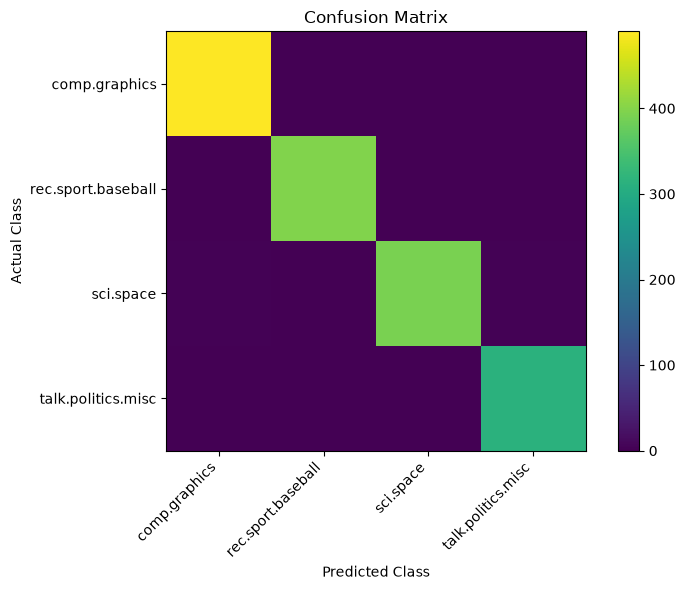

In [61]:
plt.figure(figsize=(8, 6))

plt.imshow(confusion)

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()

In [62]:
random_baseline = 1 / len(classes)

print(
    "Random Baseline:",
    random_baseline
)

Random Baseline: 0.25


In [64]:
print(
    "Naive Bayes Accuracy:",
    accuracy
)

print(
    "Random Baseline:",
    random_baseline
)

print(
    "Improvement:",
    accuracy - random_baseline
)

Naive Bayes Accuracy: 0.9968691296180339
Random Baseline: 0.25
Improvement: 0.7468691296180339


In [65]:
wrong_indices = np.where(
    test_predictions != y_test_array
)[0]

print(
    "Number of Misclassified Documents:",
    len(wrong_indices)
)

Number of Misclassified Documents: 5


In [66]:
for index in wrong_indices[:10]:

    print("\n" + "=" * 80)

    print(
        "Actual:",
        y_test_array[index]
    )

    print(
        "Predicted:",
        test_predictions[index]
    )

    print("\nDocument:")

    print(
        X_test.iloc[index][:1000]
    )


Actual: sci.space
Predicted: talk.politics.misc

Document:
Newsgroup: sci.space
document_id: 61560
From: hrubin@pop.stat.purdue.edu (Herman Rubin)
Subject: U.S. Government and Science and Technolgy Investment

In article <1993Apr30.151033.13776@aio.jsc.nasa.gov> kjenks@gothamcity.jsc.nasa.gov writes:
>People who criticize "big Government" and its projects rarely seem to
>have a consistent view of the role of Government in science and
>technology.  Basically, the U.S. Government has gotten into the role of
>supporting research which private industry finds too expensive or too
>long-term.  

>(Historically, this role for the U.S. Gov't was forced upon it because
>of socialism in other countries.  In order for U.S.  industries to
>compete with government-subsidized foreign competitors, the U.S. Gov't
>has taken on the role of subisizing big-ticket or long-lead R&D.)

This definitely had nothing to do with the entry of the government into
the support of science; some of it is relevant in 

In [67]:
errors = pd.DataFrame({
    "text": X_test.iloc[
        wrong_indices
    ].values,

    "actual": y_test_array[
        wrong_indices
    ],

    "predicted": test_predictions[
        wrong_indices
    ]
})

print(errors.head(10))

                                                text              actual  \
0  Newsgroup: sci.space\ndocument_id: 61560\nFrom...           sci.space   
1  Newsgroup: sci.space\nDocument_id: 60185\nFrom...           sci.space   
2  Newsgroup: sci.space\nDocument_id: 61560\nFrom...           sci.space   
3  Newsgroup: talk.politics.misc\nDocument_id: 17...  talk.politics.misc   
4  Newsgroup: sci.space\nDocument_id: 61519\nFrom...           sci.space   

            predicted  
0  talk.politics.misc  
1       comp.graphics  
2  talk.politics.misc  
3       comp.graphics  
4       comp.graphics  


In [68]:
error_pairs = (
    errors
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print(
    "\nMost Common Misclassifications:"
)

print(error_pairs)


Most Common Misclassifications:
actual              predicted         
sci.space           comp.graphics         2
                    talk.politics.misc    2
talk.politics.misc  comp.graphics         1
dtype: int64
